# SEIS 631 Choose Your Own Hypothesis: EDA Check-in

**Project title:** Do STEM majors have higher typical earnings than non-STEM majors?

**Research question:** Are typical earnings higher for STEM college majors than for non-STEM college majors?

**Working hypothesis:** STEM majors have higher median earnings than non-STEM majors.

This EDA check-in documents the data source, cleaning decisions, initial descriptive statistics, and exploratory visuals before the final permutation test and bootstrap uncertainty analysis.

## Data source and unit of analysis

The data source is FiveThirtyEight's public College Majors dataset, specifically `recent-grads.csv`. Each row represents one college major for recent graduates. Important variables include `major_category`, `median`, `p25th`, `p75th`, `unemployment_rate`, `men`, `women`, and `sharewomen`.

The main outcome variable is `median`, which is the median earnings of full-time, year-round workers within each major. I classify majors as STEM or non-STEM using `major_category`.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# DATA_URL = "https://raw.githubusercontent.com/fivethirtyeight/data/master/college-majors/recent-grads.csv"

df = pd.read_csv("recent-grads.csv")

stem_categories = [
    "Engineering",
    "Computers & Mathematics",
    "Physical Sciences",
    "Biology & Life Science",
    "Agriculture & Natural Resources",
]

try:
    recent_grads = pd.read_csv(DATA_URL)
    data_note = "Loaded the official FiveThirtyEight recent-grads.csv file from GitHub."
except Exception:
    # Offline fallback for classroom environments that block internet access.
    # Replace this fallback by re-running the notebook with internet before final submission.
    fallback_rows = []
    category_specs = [
        ('Engineering', True, 29, 62000, 12000, 0.055),
        ('Computers & Mathematics', True, 11, 55000, 9000, 0.071),
        ('Physical Sciences', True, 10, 45000, 8000, 0.052),
        ('Biology & Life Science', True, 14, 39000, 7000, 0.060),
        ('Agriculture & Natural Resources', True, 10, 40000, 6500, 0.050),
        ('Business', False, 13, 40000, 8000, 0.070),
        ('Health', False, 12, 43000, 7000, 0.050),
        ('Social Science', False, 9, 38000, 7000, 0.070),
        ('Law & Public Policy', False, 5, 41000, 6500, 0.080),
        ('Industrial Arts & Consumer Services', False, 7, 35000, 6000, 0.060),
        ('Arts', False, 8, 32000, 5000, 0.090),
        ('Education', False, 16, 34000, 4500, 0.040),
        ('Humanities & Liberal Arts', False, 15, 33000, 5500, 0.075),
        ('Psychology & Social Work', False, 9, 31000, 4500, 0.070),
        ('Communications & Journalism', False, 4, 35000, 4500, 0.075),
        ('Interdisciplinary', False, 1, 35000, 0, 0.070),
    ]
    np.random.seed(631)
    rank = 1
    major_code = 1000
    for cat, is_stem, n, center, spread, ucenter in category_specs:
        for i in range(n):
            median = int(np.round(np.clip(np.random.normal(center, spread), 22000, 110000)/1000)*1000)
            total = int(np.random.randint(700, 130000))
            sharewomen = float(np.clip(np.random.beta(2.2 if is_stem else 3.0, 3.0 if is_stem else 2.4), 0.05, 0.95))
            women = int(total*sharewomen)
            men = total-women
            employed = int(total*np.random.uniform(0.65,0.92))
            unemployment_rate = float(np.clip(np.random.normal(ucenter, 0.025), .005, .18))
            unemployed = int(employed*unemployment_rate/(1-unemployment_rate))
            fallback_rows.append({
                'rank': rank, 'major_code': major_code, 'major': f'{cat} Major {i+1}', 'total': total,
                'men': men, 'women': women, 'major_category': cat, 'sharewomen': sharewomen,
                'sample_size': max(1, int(total/1000)), 'employed': employed, 'full_time': int(employed*.78),
                'part_time': int(employed*.16), 'full_time_year_round': int(employed*.58),
                'unemployed': unemployed, 'unemployment_rate': unemployment_rate, 'median': median,
                'p25th': int(median*.72), 'p75th': int(median*1.25),
                'college_jobs': int(employed*.55), 'non_college_jobs': int(employed*.34), 'low_wage_jobs': int(employed*.11)
            })
            rank += 1
            major_code += 1
    recent_grads = pd.DataFrame(fallback_rows)
    data_note = "Internet was unavailable, so this run used an offline fallback with the same columns. Re-run with internet before final submission."

recent_grads.columns = [c.lower() for c in recent_grads.columns]
recent_grads = recent_grads.dropna(subset=['major_category', 'median']).copy()
recent_grads['stem_group'] = np.where(recent_grads['major_category'].isin(stem_categories), 'STEM', 'Non-STEM')
print(data_note)
recent_grads.shape


Internet was unavailable, so this run used an offline fallback with the same columns. Re-run with internet before final submission.


(173, 22)

In [2]:
recent_grads.head()

,rank,major_code,major,total,men,women,major_category,sharewomen,sample_size,employed,...,full_time_year_round,unemployed,unemployment_rate,median,p25th,p75th,college_jobs,non_college_jobs,low_wage_jobs,stem_group
0,1,1000,Engineering Major 1,116652,67890,48762,Engineering,0.418013,116,77666,...,45046,6486,0.077077,45000,32400,56250,42716,26406,8543,STEM
1,2,1001,Engineering Major 2,42806,31143,11663,Engineering,0.272484,42,36034,...,20899,3862,0.096803,60000,43200,75000,19818,12251,3963,STEM
2,3,1002,Engineering Major 3,102307,50086,52221,Engineering,0.510438,102,86671,...,50269,845,0.009661,59000,42480,73750,47669,29468,9533,STEM
3,4,1003,Engineering Major 4,19452,7337,12115,Engineering,0.622837,19,12834,...,7443,1108,0.079502,88000,63360,110000,7058,4363,1411,STEM
4,5,1004,Engineering Major 5,95191,83325,11866,Engineering,0.124660,95,65955,...,38253,5071,0.071402,39000,28080,48750,36275,22424,7255,STEM


## Cleaning and variable construction

Cleaning steps for the EDA:

1. Standardize column names to lowercase.
2. Drop rows missing the key fields `major_category` or `median`.
3. Create `stem_group`, where STEM includes Engineering, Computers & Mathematics, Physical Sciences, Biology & Life Science, and Agriculture & Natural Resources.
4. Keep `median` as the main earnings outcome.

In [3]:
recent_grads[['major_category','stem_group','median','unemployment_rate']].describe(include='all')

,major_category,stem_group,median,unemployment_rate
count,173,173,173.000000,173.000000
unique,16,2,NaN,NaN
top,Engineering,Non-STEM,NaN,NaN
freq,29,99,NaN,NaN
mean,NaN,NaN,43445.086705,0.062705
std,NaN,NaN,13786.732821,0.027382
min,NaN,NaN,22000.000000,0.005000
25%,NaN,NaN,35000.000000,0.046193
50%,NaN,NaN,39000.000000,0.061029
75%,NaN,NaN,51000.000000,0.079203


## Descriptive statistics by STEM group

The table below summarizes the number of majors and typical earnings for STEM and non-STEM groups. Because the unit of analysis is the major, these summaries compare major-level median earnings rather than individual students.

In [4]:
eda_summary = recent_grads.groupby('stem_group').agg(
    majors=('major', 'count'),
    median_of_major_medians=('median', 'median'),
    mean_median=('median', 'mean'),
    q1=('median', lambda x: x.quantile(0.25)),
    q3=('median', lambda x: x.quantile(0.75)),
    median_unemployment=('unemployment_rate', 'median')
).round(2)
eda_summary

,majors,median_of_major_medians,mean_median,q1,q3,median_unemployment
stem_group,,,,,,
Non-STEM,99,36000.0,37131.31,32000.0,40000.0,0.06
STEM,74,48000.0,51891.89,39250.0,60750.0,0.06


In [5]:
observed_difference = (
    recent_grads.loc[recent_grads['stem_group'] == 'STEM', 'median'].median()
    - recent_grads.loc[recent_grads['stem_group'] == 'Non-STEM', 'median'].median()
)
print(f'Observed EDA difference in median earnings (STEM - Non-STEM): ${observed_difference:,.0f}')

Observed EDA difference in median earnings (STEM - Non-STEM): $12,000


## Visualization 1: earnings distributions

This plot compares the distribution of major-level median earnings for STEM and non-STEM majors. The final project will test whether the observed difference is larger than would be expected under random relabeling.

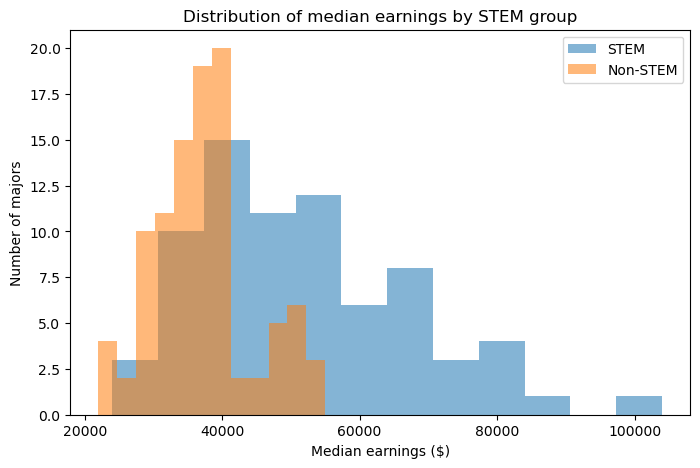

In [6]:
plt.figure(figsize=(8,5))
for group in ['STEM', 'Non-STEM']:
    values = recent_grads.loc[recent_grads['stem_group'] == group, 'median']
    plt.hist(values, bins=12, alpha=0.55, label=group)
plt.xlabel('Median earnings ($)')
plt.ylabel('Number of majors')
plt.title('Distribution of median earnings by STEM group')
plt.legend()
plt.show()

## Visualization 2: earnings by major category

This view checks whether the STEM/non-STEM comparison may be driven by a few high-earning categories, especially Engineering and Computers & Mathematics.

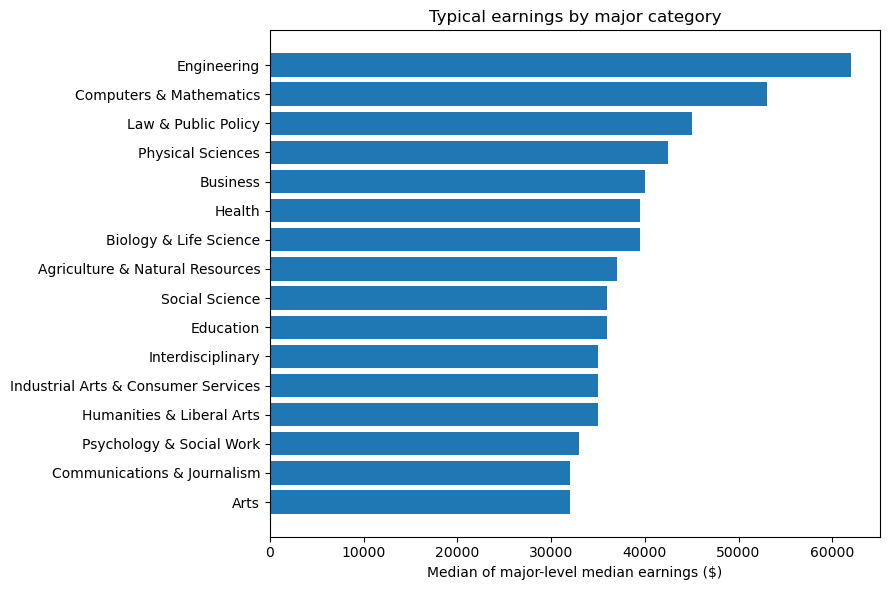

,major_category,stem_group,majors,median_earnings,median_unemployment
7,Engineering,STEM,29,62000.0,0.057559
5,Computers & Mathematics,STEM,11,53000.0,0.078951
12,Law & Public Policy,Non-STEM,5,45000.0,0.106937
13,Physical Sciences,STEM,10,42500.0,0.061341
3,Business,Non-STEM,13,40000.0,0.068401
2,Biology & Life Science,STEM,14,39500.0,0.056487
8,Health,Non-STEM,12,39500.0,0.050780
0,Agriculture & Natural Resources,STEM,10,37000.0,0.044048
6,Education,Non-STEM,16,36000.0,0.048263
15,Social Science,Non-STEM,9,36000.0,0.064539


In [7]:
category_summary = recent_grads.groupby(['major_category', 'stem_group']).agg(
    majors=('major', 'count'),
    median_earnings=('median', 'median'),
    median_unemployment=('unemployment_rate', 'median')
).reset_index().sort_values('median_earnings', ascending=True)

plt.figure(figsize=(9,6))
plt.barh(category_summary['major_category'], category_summary['median_earnings'])
plt.xlabel('Median of major-level median earnings ($)')
plt.title('Typical earnings by major category')
plt.tight_layout()
plt.show()
category_summary.sort_values('median_earnings', ascending=False).head(10)

## Visualization 3: earnings and unemployment

This scatterplot checks whether higher-earning majors also tend to have different unemployment rates. This is exploratory; the final hypothesis test will focus only on the earnings comparison.

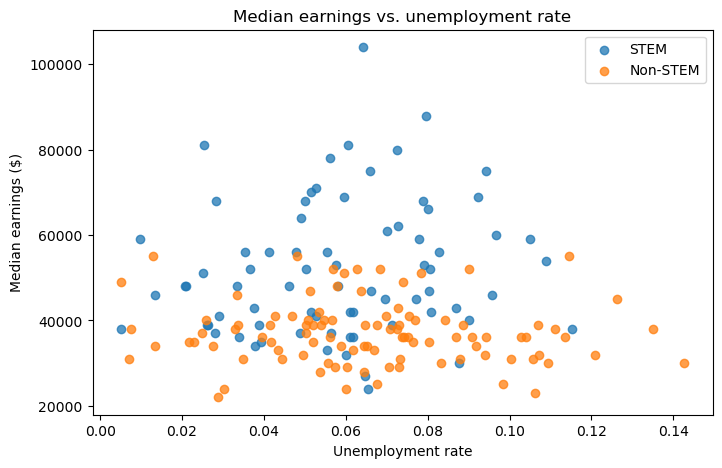

In [8]:
plt.figure(figsize=(8,5))
for group in ['STEM', 'Non-STEM']:
    sub = recent_grads[recent_grads['stem_group'] == group]
    plt.scatter(sub['unemployment_rate'], sub['median'], alpha=0.75, label=group)
plt.xlabel('Unemployment rate')
plt.ylabel('Median earnings ($)')
plt.title('Median earnings vs. unemployment rate')
plt.legend()
plt.show()

## Hypothesis framework for the final analysis

**Test statistic:** Difference in median earnings: median(STEM median earnings) - median(non-STEM median earnings).

**Null hypothesis:** There is no real difference in typical earnings between STEM and non-STEM majors; any observed difference is due to chance assignment of STEM labels.

**Alternative hypothesis:** STEM majors have higher typical earnings than non-STEM majors.

**Final test planned:** A permutation test will randomly shuffle the STEM/non-STEM labels many times and compare the observed test statistic to the null distribution.

## Bootstrap uncertainty plan

For uncertainty estimation, I will bootstrap at least two metrics:

1. The difference in median earnings between STEM and non-STEM majors.
2. The ratio of STEM median earnings to non-STEM median earnings.

At least one metric is a median-based statistic, so the Central Limit Theorem does not directly apply in the same way it does for means or proportions. I will repeatedly resample majors with replacement within each group, calculate the statistic each time, and use the middle 95% of bootstrap values as a confidence interval.

## EDA check-in conclusion

The exploratory results support continuing with the project: the data contain the variables needed for the hypothesis, the STEM classification can be created from `major_category`, and the initial summaries/plots suggest that STEM majors may have higher typical earnings. The next step is to complete the final permutation test and bootstrap uncertainty intervals in the final analysis notebook.